# Multi-Objective Optimization of Quantum Circuits with NSGA-III

This notebook adapts the methodology of the `AG_multi_objectifs_VF.ipynb` notebook (based on **NSGA-II**)
to use **NSGA-III** instead.

The three objectives remain identical:

1. **Fidelity** to the target circuit (to maximize)
2. **Depth** of the circuit (to minimize)
3. Total gate **cost** (to minimize)

## Main Differences between NSGA-II and NSGA-III

| Aspect | NSGA-II | NSGA-III |
|---|---|---|
| Front sorting | Fast non-dominated sort | Identical (fast non-dominated sort) |
| Diversity preservation | *Crowding* distance | Structured reference points (Das & Dennis method) + niching |
| Parent selection | Tournament (rank + crowding distance) | Tournament (rank) or random selection |
| Environmental selection | Front-based filling + crowding distance | Front-based filling + reference point association + niching |
| Ideal for | 2-3 objectives | 3+ objectives (but also works very well with 3) |

The core of the implementation therefore changes at the **environmental selection** level:
NSGA-III replaces the *crowding* distance with a *niching* procedure based on reference
points uniformly distributed on a normalized hyperplane.

In [1]:
pip install qiskit


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pylatexenc


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
## Imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt
import copy
import random
import itertools
from joblib import Parallel, delayed
import time
import math
from numpy import pi

## Seed Configuration

Identical to the NSGA-II notebook, to ensure reproducibility of results.

In [5]:
# -------------------- Seed Configuration --------------------
def set_random_seeds(seed=42):
    """Configures all random seeds for reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.Set1.colors)
    print(f"🌱 Seeds configured: {seed}")

## Gate Costs

Identical to the NSGA-II notebook.

In [6]:
# -------------------- Gate Costs --------------------
GATE_COSTS = {
    'NOT': 1,
    'Phase': 1,
    'H': 2,      # Hadamard
    'X': 1,
    'Y': 1,
    'Z': 1,
    'CX': 5,     # Equivalent to CNOT
    'SWAP': 11,
    'Peres': 12,
    'Toffoli': 13,
    'Fredkin': 19,
    'Miller': 24,
    'RX': 1,     # Rotation gates
    'RY': 1,
    'RZ': 1
}

## Circuit Representation (chromosomes)

Identical to the NSGA-II notebook: a circuit is encoded as a list of genes
`[target_qubit, gate, control_qubit, angle]`.

In [7]:
# -------------------- Circuit Generation --------------------
def generate_gene(num_qubits):
    """Generates a random gene representing a quantum gate."""
    quantum_gates = {
        "H": {"control": False, "rotation": False},
        "X": {"control": False, "rotation": False},
        "Y": {"control": False, "rotation": False},
        "Z": {"control": False, "rotation": False},
        "CX": {"control": True, "rotation": False},
        "RX": {"control": False, "rotation": True},
        "RY": {"control": False, "rotation": True},
        "RZ": {"control": False, "rotation": True}
    }

    target_qubit = np.random.randint(num_qubits)
    gate = np.random.choice(list(quantum_gates.keys()))
    control_qubit = None
    angle = None

    if quantum_gates[gate]["control"]:
        control_qubit = np.random.randint(num_qubits)
        while control_qubit == target_qubit:
            control_qubit = np.random.randint(num_qubits)

    if quantum_gates[gate]["rotation"]:
        angle = np.random.uniform(0, 2 * np.pi)

    return [target_qubit, gate, control_qubit, angle]


def generate_chromosome(num_qubits, num_genes):
    """Generates a chromosome (sequence of genes)."""
    return [generate_gene(num_qubits) for _ in range(num_genes)]


def generate_population(pop_size, num_qubits, num_genes):
    """Generates a population of chromosomes."""
    return [generate_chromosome(num_qubits, num_genes) for _ in range(pop_size)]


def create_quantum_circuit(chromosome, num_qubits):
    """Transforms a chromosome into a Qiskit quantum circuit."""
    circuit = QuantumCircuit(num_qubits)

    for gene in chromosome:
        target, gate, control, angle = gene

        if gate in ["H", "X", "Y", "Z"]:
            getattr(circuit, gate.lower())(target)
        elif gate == "CX":
            circuit.cx(control, target)
        elif gate in ["RX", "RY", "RZ"]:
            getattr(circuit, gate.lower())(angle, target)

    return circuit

## Multi-objective Evaluation Functions

Identical to the NSGA-II notebook. Each individual is evaluated on three objectives, all
returned in a form **to maximize**: `[fidelity, -depth, -cost]`.

In [8]:
# -------------------- Multi-objective Evaluation Functions --------------------
def compute_fidelity(circuit, target_unitary):
    """Computes the fidelity of the circuit relative to the target unitary."""
    candidate_unitary = Operator(circuit).data
    target_dagger = np.conj(target_unitary).T
    trace_value = np.trace(np.dot(candidate_unitary, target_dagger))
    num_qubits = circuit.num_qubits
    return np.abs(trace_value) / (2 ** num_qubits)


def compute_circuit_depth(circuit):
    """Computes the depth of the circuit."""
    return circuit.depth()


def compute_circuit_cost(chromosome):
    """Computes the total cost of the circuit based on the gates used."""
    total_cost = 0
    for gene in chromosome:
        gate = gene[1]
        total_cost += GATE_COSTS.get(gate, 1)
    return total_cost


def evaluate_individual(chromosome, num_qubits, target_unitary):
    """Evaluates an individual on the three objectives (all to MAXIMIZE)."""
    circuit = create_quantum_circuit(chromosome, num_qubits)

    fidelity = compute_fidelity(circuit, target_unitary)
    depth = compute_circuit_depth(circuit)
    cost = compute_circuit_cost(chromosome)

    # [fidelity, -depth, -cost] -> all 3 objectives are to maximize
    return [fidelity, -depth, -cost]


def parallel_evaluation(population, num_qubits, target_unitary):
    """Parallel evaluation of the population."""
    return Parallel(n_jobs=-1)(
        delayed(evaluate_individual)(chromo, num_qubits, target_unitary)
        for chromo in population
    )

## Individual Class (NSGA-III version)

Lighter than the NSGA-II version: we no longer need `crowding_distance`,
`dominated_by` or `dominates` stored on the object. We only keep the `rank`
(needed for the parent tournament selection).

In [9]:
# -------------------- Individual Class (NSGA-III) --------------------
class NSGA3Individual:
    def __init__(self, chromosome, fitness_values=None):
        self.chromosome = chromosome
        self.fitness_values = fitness_values  # [fidelity, -depth, -cost] (to maximize)
        self.rank = None  # Pareto rank (0 = non-dominated front)

## Non-dominated Sort (identical to NSGA-II)

The *fast non-dominated sort* of Deb et al. (2002) is **common**
to NSGA-II and NSGA-III: only the selection step within the last retained
front differs (crowding distance vs. niching by reference points).

In [10]:
# -------------------- Non-dominated Sort (shared with NSGA-II) --------------------
def dominates(fitness_a, fitness_b):
    """a dominates b if a is >= b on all objectives and > on at least one (maximization)."""
    better_in_all = all(fitness_a[i] >= fitness_b[i] for i in range(len(fitness_a)))
    better_in_at_least_one = any(fitness_a[i] > fitness_b[i] for i in range(len(fitness_a)))
    return better_in_all and better_in_at_least_one


def fast_non_dominated_sort(population):
    """Sorts the population into Pareto fronts (front 0 = best) and updates .rank."""
    n = len(population)
    dominated_solutions = [[] for _ in range(n)]
    domination_count = [0] * n
    fronts = [[]]

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if dominates(population[i].fitness_values, population[j].fitness_values):
                dominated_solutions[i].append(j)
            elif dominates(population[j].fitness_values, population[i].fitness_values):
                domination_count[i] += 1
        if domination_count[i] == 0:
            population[i].rank = 0
            fronts[0].append(i)

    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in dominated_solutions[i]:
                domination_count[j] -= 1
                if domination_count[j] == 0:
                    population[j].rank = k + 1
                    next_front.append(j)
        k += 1
        fronts.append(next_front)

    return fronts[:-1]  # last front is empty, remove it

## Reference Points (Das & Dennis method)

This is the **NSGA-III-specific core**: instead of a crowding distance, a set of
reference points distributed **uniformly** over the normalized hyperplane
`f1 + f2 + f3 = 1` is generated (in the normalized objective space). These reference
points guide the selection to ensure good solution diversity along the Pareto
front.

The number of points generated for `M` objectives with `p` divisions is
`C(p + M - 1, M - 1)`. For `M = 3` (our 3 objectives) and `p = 12`, we get 91 points.

In [11]:
# -------------------- Reference Points (Das & Dennis) --------------------
def generate_reference_points(num_objectives, num_divisions):
    """Generates structured reference points on the normalized hyperplane (Das & Dennis, 1998).

    Returns an array (num_points, num_objectives) whose each row sums to 1.
    """
    points = []

    def recurse(remaining, depth, current):
        if depth == num_objectives - 1:
            current.append(remaining)
            points.append(list(current))
            current.pop()
            return
        for i in range(remaining + 1):
            current.append(i)
            recurse(remaining - i, depth + 1, current)
            current.pop()

    recurse(num_divisions, 0, [])
    reference_points = np.array(points, dtype=float) / num_divisions
    return reference_points

## Normalization and Association to Reference Points

Before each individual can be associated with a reference point, the objectives must be
normalized (since fidelity, depth and cost do not share the same scale). The standard
NSGA-III procedure is:

1. Compute the **ideal point** `z*` (minimum per objective, in minimization).
2. Compute the **extreme points** via an Achievement Scalarizing Function (ASF) to
   construct the hyperplane.
3. Derive the hyperplane's **intercepts** with each axis, then normalize.
4. **Associate** each individual with the reference point whose line (origin → reference
   point) is closest (perpendicular distance).

⚠️ Our objectives are stored **to maximize** (`[fidelity, -depth, -cost]`). NSGA-III is
classically formulated as a **minimization** problem; we therefore convert internally
(`F = -fitness_values`) only for this normalization/association step.

In [12]:
# -------------------- Normalization --------------------
def normalize_objectives(F, ideal_point):
    """Normalizes the objectives (to minimize) relative to the ideal point and the intercepts
    computed via the extreme points (standard NSGA-III procedure)."""
    num_objectives = F.shape[1]
    F_translated = F - ideal_point

    # Extreme points via Achievement Scalarizing Function (ASF)
    extreme_points = np.zeros((num_objectives, num_objectives))
    for m in range(num_objectives):
        weights = np.full(num_objectives, 1e-6)
        weights[m] = 1.0
        asf_values = np.max(F_translated / weights, axis=1)
        extreme_points[m] = F_translated[np.argmin(asf_values)]

    # Intercepts of the hyperplane defined by the extreme points: sum(f_i / a_i) = 1
    try:
        coeffs = np.linalg.solve(extreme_points, np.ones(num_objectives))
        intercepts = 1.0 / coeffs
        if np.any(intercepts <= 1e-10) or np.any(~np.isfinite(intercepts)):
            raise np.linalg.LinAlgError
    except np.linalg.LinAlgError:
        # Degenerate case (undefined hyperplane): fall back to the nadir point
        intercepts = np.max(F_translated, axis=0)
        intercepts[intercepts < 1e-10] = 1e-10

    F_normalized = F_translated / intercepts
    return F_normalized


# -------------------- Association to Reference Points --------------------
def associate_to_reference_points(F_normalized, reference_points):
    """Associates each normalized individual with the closest reference point
    (perpendicular distance to the origin -> reference point line)."""
    ref_norms = np.linalg.norm(reference_points, axis=1, keepdims=True)
    ref_norms[ref_norms == 0] = 1e-12
    ref_unit_vectors = reference_points / ref_norms

    n_individuals = F_normalized.shape[0]
    associated_ref = np.zeros(n_individuals, dtype=int)
    associated_dist = np.zeros(n_individuals)

    for i in range(n_individuals):
        f = F_normalized[i]
        projection_scalars = f @ ref_unit_vectors.T
        projection_points = projection_scalars[:, None] * ref_unit_vectors
        distances = np.linalg.norm(f[None, :] - projection_points, axis=1)
        best_ref = np.argmin(distances)
        associated_ref[i] = best_ref
        associated_dist[i] = distances[best_ref]

    return associated_ref, associated_dist

## Environmental Selection by Niching (the core of NSGA-III)

This is the step that **replaces the crowding distance** of NSGA-II:

1. The Pareto fronts (`F1, F2, ...`) are stacked until the desired population size is
   exceeded. The last front added (`F_l`) is the one that must be *partially* selected.
2. **All** already accepted individuals + those from `F_l` are normalized and associated
   with the reference points, and the number of individuals (`niche count`) already
   associated with each reference point is counted.
3. Individuals from `F_l` are iteratively selected, favoring the **least represented**
   reference points (lowest niche count), until the desired population size is reached.

This procedure guarantees a homogeneous distribution of solutions along the whole Pareto
front, rather than simply favoring the least dense areas (as the crowding distance does).

In [13]:
# -------------------- NSGA-III Environmental Selection (niching) --------------------
def niching_selection(fronts, population, reference_points, pop_size):
    """Selects pop_size individuals from the Pareto fronts using the
    NSGA-III niching procedure (Deb & Jain, 2014)."""

    # 1) Stack complete fronts as long as the size does not exceed pop_size
    selected_indices = []
    front_idx = 0
    while front_idx < len(fronts) and len(selected_indices) + len(fronts[front_idx]) <= pop_size:
        selected_indices.extend(fronts[front_idx])
        front_idx += 1

    if len(selected_indices) == pop_size:
        return [population[i] for i in selected_indices]

    if front_idx >= len(fronts):
        return [population[i] for i in selected_indices]

    last_front = fronts[front_idx]
    k_needed = pop_size - len(selected_indices)

    # 2) Normalize on St = (already accepted individuals) U (last front)
    st_indices = selected_indices + last_front
    F = np.array([[-v for v in population[i].fitness_values] for i in st_indices])  # -> minimization

    ideal_point = np.min(F, axis=0)
    F_normalized = normalize_objectives(F, ideal_point)
    associated_ref, associated_dist = associate_to_reference_points(F_normalized, reference_points)

    n_accepted = len(selected_indices)
    accepted_assoc = associated_ref[:n_accepted]
    last_front_local_positions = list(range(n_accepted, len(st_indices)))
    last_front_assoc = associated_ref[n_accepted:]

    num_refs = reference_points.shape[0]
    niche_count = np.zeros(num_refs, dtype=int)
    for ref in accepted_assoc:
        niche_count[ref] += 1

    # Candidates (from the last front, local positions in st_indices) per reference point
    candidates_per_ref = {j: [] for j in range(num_refs)}
    for local_pos, ref_j in zip(last_front_local_positions, last_front_assoc):
        candidates_per_ref[ref_j].append(local_pos)

    chosen_local_positions = []
    excluded_refs = set()

    # 3) Niching loop: complete the population with the least represented points
    while len(chosen_local_positions) < k_needed:
        available_refs = [j for j in range(num_refs)
                           if j not in excluded_refs and len(candidates_per_ref[j]) > 0]
        if not available_refs:
            break  # safety net (should not happen if k_needed <= len(last_front))

        min_niche_count = min(niche_count[j] for j in available_refs)
        tied_refs = [j for j in available_refs if niche_count[j] == min_niche_count]
        chosen_ref = random.choice(tied_refs)

        if niche_count[chosen_ref] == 0:
            # first individual for this reference point -> the closest one
            candidates = candidates_per_ref[chosen_ref]
            distances = [associated_dist[c] for c in candidates]
            picked = candidates[int(np.argmin(distances))]
        else:
            # reference point already represented -> random choice among the candidates
            picked = random.choice(candidates_per_ref[chosen_ref])

        chosen_local_positions.append(picked)
        candidates_per_ref[chosen_ref].remove(picked)
        niche_count[chosen_ref] += 1
        if len(candidates_per_ref[chosen_ref]) == 0:
            excluded_refs.add(chosen_ref)

    final_indices = selected_indices + [st_indices[p] for p in chosen_local_positions]
    return [population[i] for i in final_indices]

## Genetic Operators

Identical to the NSGA-II notebook (one-point crossover, gene mutation and structural
mutation). Only the selection of **parents** changes slightly: in NSGA-III, diversity is
already ensured by niching during environmental selection, so a simple **binary
tournament based on Pareto rank** is enough (no need for crowding distance here).

In [14]:
# -------------------- Genetic Operators --------------------
def crossover(parent1, parent2):
    """One-point crossover between two parents."""
    min_length = min(len(parent1), len(parent2))
    if min_length < 2:
        return parent1.copy(), parent2.copy()

    cut_point = np.random.randint(1, min_length)
    child1 = parent1[:cut_point] + parent2[cut_point:]
    child2 = parent2[:cut_point] + parent1[cut_point:]

    return child1, child2


def mutate(chromosome, num_qubits, mutation_rate=0.1):
    """Mutation of a chromosome (gene mutation + structural mutation)."""
    if np.random.rand() < mutation_rate:
        if len(chromosome) > 0:
            idx = np.random.randint(len(chromosome))
            chromosome[idx] = generate_gene(num_qubits)

    if np.random.rand() < 0.1:
        if np.random.rand() < 0.5 and len(chromosome) > 1:
            idx = np.random.randint(len(chromosome))
            del chromosome[idx]
        else:
            new_gene = generate_gene(num_qubits)
            idx = np.random.randint(len(chromosome) + 1)
            chromosome.insert(idx, new_gene)

    return chromosome


def binary_tournament_by_rank(population):
    """Binary tournament selection based solely on Pareto rank
    (diversity being handled by niching during environmental selection)."""
    a, b = random.sample(population, 2)
    if a.rank < b.rank:
        return a
    elif b.rank < a.rank:
        return b
    return random.choice([a, b])

## NSGA-III Genetic Algorithm

The main loop follows exactly the same structure as NSGA-II
(`AG_multi_objectifs_VF.ipynb`):

1. Initialize a random population and evaluate it.
2. At each generation:
   - Generate a population of children (tournament selection + crossover + mutation).
   - Merge parents + children.
   - Sort into Pareto fronts (non-dominated sort).
   - **NSGA-III environmental selection** (niching by reference points) instead of the
     crowding distance, to obtain the new generation.
3. Return the final Pareto front.

In [15]:
# -------------------- NSGA-III Genetic Algorithm --------------------
def multi_objective_genetic_algorithm_nsga3(num_qubits, num_genes, pop_size, generations,
                                             target_unitary, num_divisions=12,
                                             mutation_rate=0.1, crossover_rate=0.9):
    """Main multi-objective genetic algorithm, based on NSGA-III."""

    # Structured reference points (Das & Dennis) on the normalized hyperplane
    reference_points = generate_reference_points(num_objectives=3, num_divisions=num_divisions)
    print(f"📐 Reference points generated: {len(reference_points)}")

    # Initialize the population
    chromosomes = generate_population(pop_size, num_qubits, num_genes)
    fitness_values = parallel_evaluation(chromosomes, num_qubits, target_unitary)

    population = [NSGA3Individual(chromo, fitness)
                  for chromo, fitness in zip(chromosomes, fitness_values)]
    fast_non_dominated_sort(population)  # initializes .rank for the 1st tournament

    # History of Pareto fronts
    pareto_history = []

    for generation in range(generations):
        print(f"\nGeneration {generation + 1}/{generations}")

        # Save the current Pareto front (rank 0)
        fronts = fast_non_dominated_sort(population)
        pareto_front = [population[i] for i in fronts[0]]
        pareto_history.append(pareto_front)

        fidelities = [ind.fitness_values[0] for ind in pareto_front]
        depths = [-ind.fitness_values[1] for ind in pareto_front]
        costs = [-ind.fitness_values[2] for ind in pareto_front]

        print(f"Pareto front: {len(pareto_front)} solutions")
        print(f"Fidelity: {np.mean(fidelities):.4f} ± {np.std(fidelities):.4f}")
        print(f"Depth: {np.mean(depths):.2f} ± {np.std(depths):.2f}")
        print(f"Cost: {np.mean(costs):.2f} ± {np.std(costs):.2f}")

        # Create the new generation (children)
        offspring_chromosomes = []
        while len(offspring_chromosomes) < pop_size:
            parent1 = binary_tournament_by_rank(population)
            parent2 = binary_tournament_by_rank(population)

            if np.random.rand() < crossover_rate:
                child1_chromo, child2_chromo = crossover(parent1.chromosome, parent2.chromosome)
            else:
                child1_chromo, child2_chromo = parent1.chromosome.copy(), parent2.chromosome.copy()

            child1_chromo = mutate(child1_chromo, num_qubits, mutation_rate)
            child2_chromo = mutate(child2_chromo, num_qubits, mutation_rate)

            offspring_chromosomes.append(child1_chromo)
            if len(offspring_chromosomes) < pop_size:
                offspring_chromosomes.append(child2_chromo)

        offspring_fitness = parallel_evaluation(offspring_chromosomes, num_qubits, target_unitary)
        offspring = [NSGA3Individual(chromo, fitness)
                     for chromo, fitness in zip(offspring_chromosomes, offspring_fitness)]

        # Merge parents + children, non-dominated sort
        combined_population = population + offspring
        fronts = fast_non_dominated_sort(combined_population)

        # NSGA-III environmental selection (niching by reference points)
        population = niching_selection(fronts, combined_population, reference_points, pop_size)
        fast_non_dominated_sort(population)  # updates ranks for the next tournament

    # Final Pareto front
    final_fronts = fast_non_dominated_sort(population)
    final_pareto_front = [population[i] for i in final_fronts[0]]

    return final_pareto_front, pareto_history, reference_points

## Visualization

Same plots as the NSGA-II notebook (3D Pareto front, objective evolution),
plus an additional visualization specific to NSGA-III: the **reference points**
used to guide selection diversity.

In [16]:
# -------------------- Visualization --------------------
def plot_pareto_front_3d(pareto_front):
    """Visualizes the Pareto front in 3D."""
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    fidelities = [ind.fitness_values[0] for ind in pareto_front]
    depths = [-ind.fitness_values[1] for ind in pareto_front]
    costs = [-ind.fitness_values[2] for ind in pareto_front]

    scatter = ax.scatter(fidelities, depths, costs, c=costs, cmap='viridis', s=100)

    ax.set_xlabel('Fidelity')
    ax.set_ylabel('Depth')
    ax.set_zlabel('Cost')
    ax.set_title('Pareto Front - NSGA-III')

    plt.colorbar(scatter, label='Cost')
    plt.tight_layout()
    plt.show()


def plot_pareto_evolution(pareto_history):
    """Visualizes the evolution of the Pareto front over generations."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    generations = range(len(pareto_history))

    avg_fidelities = [np.mean([ind.fitness_values[0] for ind in front]) for front in pareto_history]
    max_fidelities = [np.max([ind.fitness_values[0] for ind in front]) for front in pareto_history]

    axes[0].plot(generations, avg_fidelities, 'b-', label='Mean')
    axes[0].plot(generations, max_fidelities, 'r-', label='Maximum')
    axes[0].set_xlabel('Generations')
    axes[0].set_ylabel('Fidelity')
    axes[0].set_title('Fidelity Evolution')
    axes[0].legend()
    axes[0].grid(True)

    avg_depths = [np.mean([-ind.fitness_values[1] for ind in front]) for front in pareto_history]
    min_depths = [np.min([-ind.fitness_values[1] for ind in front]) for front in pareto_history]

    axes[1].plot(generations, avg_depths, 'b-', label='Mean')
    axes[1].plot(generations, min_depths, 'g-', label='Minimum')
    axes[1].set_xlabel('Generations')
    axes[1].set_ylabel('Depth')
    axes[1].set_title('Depth Evolution')
    axes[1].legend()
    axes[1].grid(True)

    avg_costs = [np.mean([-ind.fitness_values[2] for ind in front]) for front in pareto_history]
    min_costs = [np.min([-ind.fitness_values[2] for ind in front]) for front in pareto_history]

    axes[2].plot(generations, avg_costs, 'b-', label='Mean')
    axes[2].plot(generations, min_costs, 'r-', label='Minimum')
    axes[2].set_xlabel('Generations')
    axes[2].set_ylabel('Cost')
    axes[2].set_title('Cost Evolution')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


def plot_reference_points(reference_points):
    """Visualizes the reference points on the normalized hyperplane (specific to NSGA-III)."""
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(reference_points[:, 0], reference_points[:, 1], reference_points[:, 2],
               c='darkorange', s=40, edgecolor='k')

    ax.set_xlabel('f1 (fidelity, normalized)')
    ax.set_ylabel('f2 (depth, normalized)')
    ax.set_zlabel('f3 (cost, normalized)')
    ax.set_title(f'{len(reference_points)} reference points (Das & Dennis)\nhyperplane f1+f2+f3=1')
    plt.tight_layout()
    plt.show()

## Target Circuit

Test circuit identical to the NSGA-II notebook.

In [17]:
# -------------------- Test Circuit --------------------
def create_target_circuit(num_qubits=4, num_layers=4):
    """Creates a target circuit for testing."""
    qc = QuantumCircuit(num_qubits)

    for i in range(num_qubits):
        qc.h(i)

    for layer in range(num_layers):
        for j in range(num_qubits - 1):
            qc.cx(j, j + 1)

    for i in range(num_qubits):
        qc.rz((i + 1) * np.pi / 14, i)

    print("🎯 Target Circuit:")
    fig, ax = plt.subplots(figsize=(6, 3))
    qc.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()

    return Operator(qc).data

## Main Execution

Same parameters as the NSGA-II notebook (4 qubits, 12 genes, 100 individuals, 200
generations) to facilitate direct comparison of the two algorithms.
`num_divisions=12` gives 91 reference points for 3 objectives
(`C(12+3-1, 3-1) = C(14,2) = 91`), a number close to the population size.

🌱 Seeds configured: 29
🎯 Target Circuit:


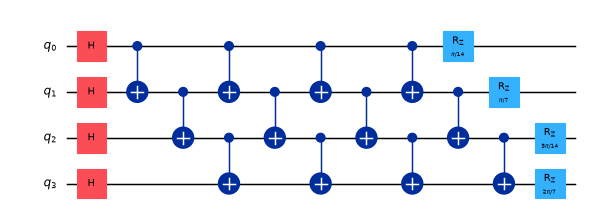

🚀 Starting multi-objective optimization (NSGA-III)...
Parameters: 4 qubits, 12 genes, 100 individuals, 200 generations, 12 reference divisions
📐 Reference points generated: 91

Generation 1/200
Pareto front: 6 solutions
Fidelity: 0.1088 ± 0.1247
Depth: 4.17 ± 0.69
Cost: 14.17 ± 1.57

Generation 2/200
Pareto front: 8 solutions
Fidelity: 0.1701 ± 0.1303
Depth: 4.38 ± 0.70
Cost: 13.75 ± 2.05

Generation 3/200
Pareto front: 10 solutions
Fidelity: 0.1986 ± 0.1098
Depth: 4.20 ± 0.75
Cost: 13.60 ± 2.06

Generation 4/200
Pareto front: 16 solutions
Fidelity: 0.1718 ± 0.1177
Depth: 4.12 ± 0.78
Cost: 12.94 ± 1.89

Generation 5/200
Pareto front: 15 solutions
Fidelity: 0.1084 ± 0.1164
Depth: 3.67 ± 0.60
Cost: 11.67 ± 1.30

Generation 6/200
Pareto front: 11 solutions
Fidelity: 0.1378 ± 0.1245
Depth: 3.36 ± 0.48
Cost: 11.91 ± 1.31

Generation 7/200
Pareto front: 13 solutions
Fidelity: 0.1585 ± 0.1459
Depth: 3.38 ± 0.49
Cost: 12.08 ± 1.54

Generation 8/200
Pareto front: 9 solutions
Fidelity: 0.3066 ± 

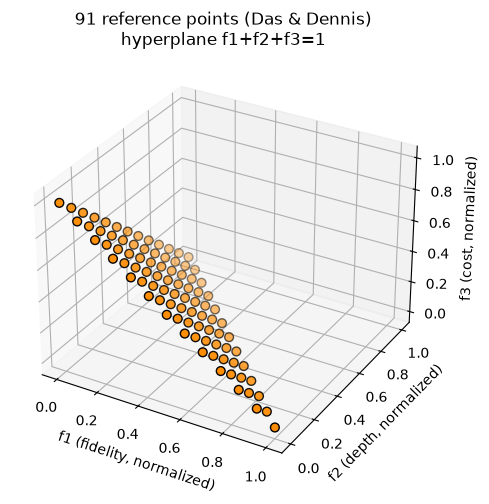

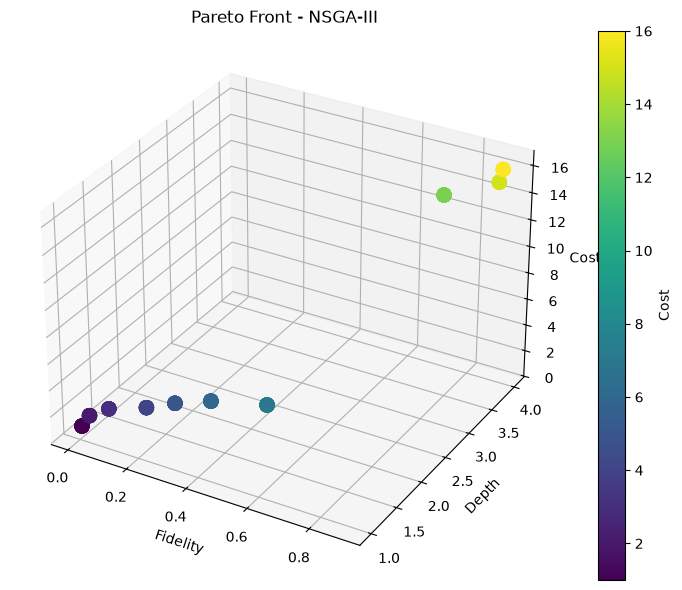

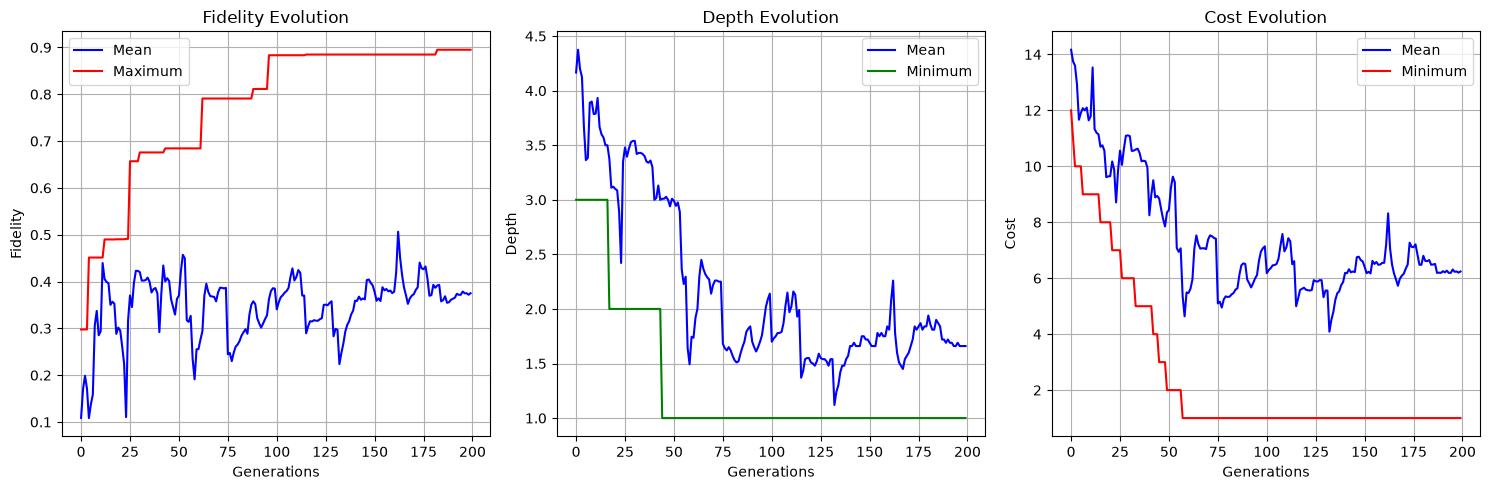


🏆 Best circuit (fidelity):
Fidelity: 0.8951
Depth: 4
Cost: 16
Optimized Circuit: 


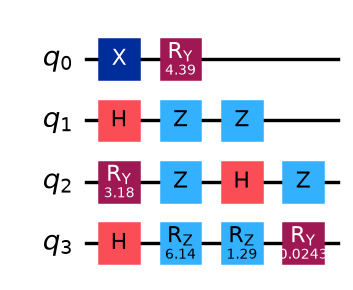

In [18]:
if __name__ == "__main__":

    MASTER_SEED = 29
    set_random_seeds(MASTER_SEED)

    # Parameters (identical to the NSGA-II notebook for direct comparison)
    num_qubits = 4
    num_genes = 12
    pop_size = 100
    generations = 200
    num_divisions = 12  # -> 91 reference points for 3 objectives

    # Create the target circuit
    target_unitary = create_target_circuit(num_qubits)

    print("🚀 Starting multi-objective optimization (NSGA-III)...")
    print(f"Parameters: {num_qubits} qubits, {num_genes} genes, {pop_size} individuals, "
          f"{generations} generations, {num_divisions} reference divisions")

    # Run the algorithm
    pareto_front, pareto_history, reference_points = multi_objective_genetic_algorithm_nsga3(
        num_qubits, num_genes, pop_size, generations, target_unitary,
        num_divisions=num_divisions, mutation_rate=0.1, crossover_rate=0.9
    )

    print(f"\n🎯 Optimization finished!")
    print(f"Final Pareto front: {len(pareto_front)} solutions")

    # Display the best solutions
    print("\n📊 Top 5 solutions from the Pareto front (sorted by fidelity):")
    top5 = sorted(pareto_front, key=lambda ind: ind.fitness_values[0], reverse=True)[:5]
    for i, ind in enumerate(top5):
        fidelity = ind.fitness_values[0]
        depth = -ind.fitness_values[1]
        cost = -ind.fitness_values[2]

        print(f"Solution {i+1}: Fidelity={fidelity:.4f}, Depth={depth:.0f}, Cost={cost:.0f}")
        print(f"  Circuit: {len(ind.chromosome)} gates")

    # Visualizations
    plot_reference_points(reference_points)
    plot_pareto_front_3d(pareto_front)
    plot_pareto_evolution(pareto_history)

    # Display an optimal circuit
    best_fidelity_ind = max(pareto_front, key=lambda x: x.fitness_values[0])
    best_circuit = create_quantum_circuit(best_fidelity_ind.chromosome, num_qubits)

    print(f"\n🏆 Best circuit (fidelity):")
    print(f"Fidelity: {best_fidelity_ind.fitness_values[0]:.4f}")
    print(f"Depth: {-best_fidelity_ind.fitness_values[1]:.0f}")
    print(f"Cost: {-best_fidelity_ind.fitness_values[2]:.0f}")
    print("Optimized Circuit: ")
    fig, ax = plt.subplots(figsize=(6, 3))
    best_circuit.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()